1. Environment Setup

In [1]:
# CELL 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Set paths
base_path = Path('C:/Users/ericm/Portfolio Projects/Transport-Operations-Analysis/04-liebherr-spare-parts-optimisation')
data_path = base_path / 'data'
charts_path = base_path / 'charts'

# Ensure directories exist
data_path.mkdir(parents=True, exist_ok=True)
charts_path.mkdir(parents=True, exist_ok=True)

print('✓ Libraries imported successfully')


✓ Libraries imported successfully


2. Equipment Population Mapping
Code:

In [2]:
equipment_data = {
    'Site': ['Dawson Mine', 'Dawson Mine', 'Dawson Mine', 'Dawson Mine', 'Mt Arthur Coal', 'Mt Arthur Coal', 'Mt Arthur Coal', 'Peak Downs', 'Peak Downs', 'Peak Downs', 'Fortescue Operations'],
    'Operator': ['MacKellar Mining (Anglo American contractor)', 'MacKellar Mining', 'MacKellar Mining', 'MacKellar Mining', 'BHP', 'BHP', 'BHP', 'BHP Mitsubishi Alliance', 'BHP Mitsubishi Alliance', 'BHP Mitsubishi Alliance', 'Fortescue Metals Group'],
    'Region': ['Bowen Basin QLD', 'Bowen Basin QLD', 'Bowen Basin QLD', 'Bowen Basin QLD', 'Bowen Basin QLD', 'Bowen Basin QLD', 'Bowen Basin QLD', 'Bowen Basin QLD', 'Bowen Basin QLD', 'Bowen Basin QLD', 'Pilbara WA'],
    'Equipment_Model': ['R996B', 'R9400', 'T264', 'PR776', 'T282C', 'R996', 'R994B', 'T282C', 'R996B', 'R9800', 'T264'],
    'Equipment_Type': ['Hydraulic Excavator', 'Hydraulic Excavator', 'Mining Haul Truck', 'Mining Dozer', 'Ultra-Class Haul Truck', 'Hydraulic Excavator', 'Hydraulic Excavator', 'Ultra-Class Haul Truck', 'Hydraulic Excavator', 'Hydraulic Excavator', 'Zero-Emission Haul Truck'],
    'Operating_Weight_tonnes': [672, 345, 240, 70, 363, 672, 625, 363, 672, 800, 240],
    'Quantity': [5, 2, 5, 1, 61, 8, 2, 5, 3, 2, 109],
    'Source': ['Liebherr Press Release 2020', 'Liebherr Press Release 2020', 'Liebherr Press Release 2020', 'Liebherr Press Release 2020', 'Australian Mining Review 2025', 'Australian Mining Review 2025', 'Australian Mining Review 2025', 'NS Energy 2020', 'NS Energy 2020', 'NS Energy 2020', 'International Mining 2024'],
    'Year': [2020, 2020, 2020, 2020, 2025, 2025, 2025, 2018, 2020, 2020, 2025]
}

equipment_df = pd.DataFrame(equipment_data)
total_equipment = equipment_df['Quantity'].sum()

print(f'\nTotal Equipment Units: {total_equipment}')
print(f'\nEquipment by Type:')
print(equipment_df.groupby('Equipment_Type')['Quantity'].sum().to_string())
print(f'\nEquipment by Region:')
print(equipment_df.groupby('Region')['Quantity'].sum().to_string())



Total Equipment Units: 203

Equipment by Type:
Equipment_Type
Hydraulic Excavator          22
Mining Dozer                  1
Mining Haul Truck             5
Ultra-Class Haul Truck       66
Zero-Emission Haul Truck    109

Equipment by Region:
Region
Bowen Basin QLD     94
Pilbara WA         109


2.1 Fleet Distribution Visualisation

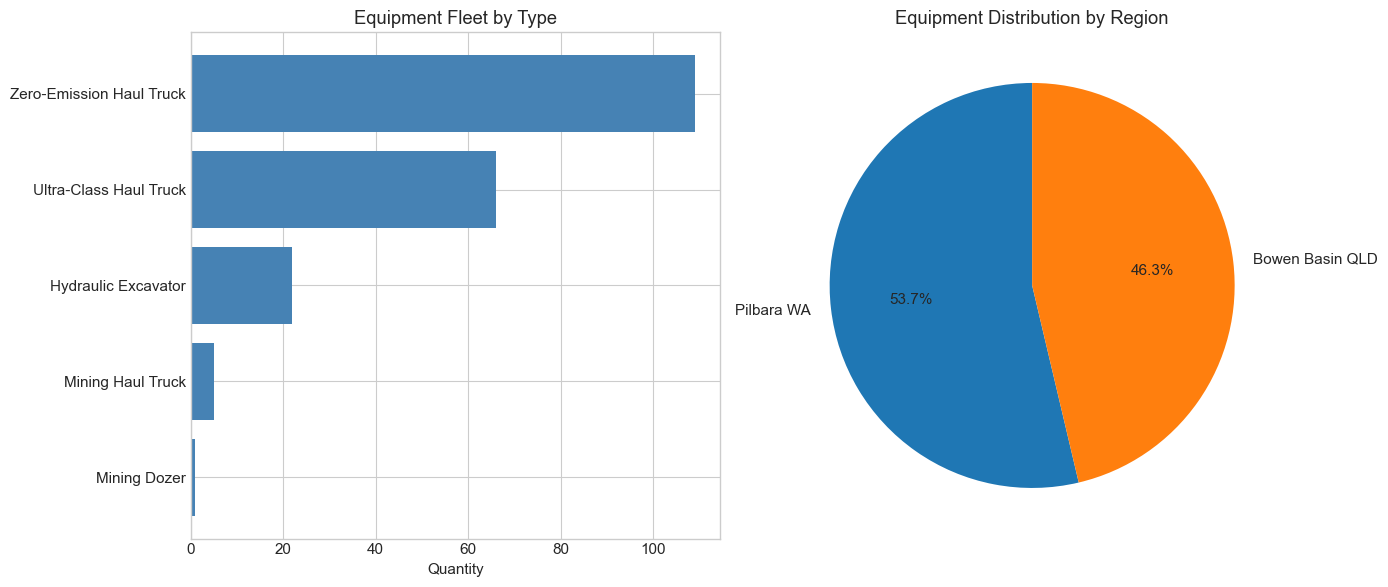

In [3]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart A: Equipment by Type
type_counts = equipment_df.groupby('Equipment_Type')['Quantity'].sum().sort_values(ascending=False)
ax1.barh(type_counts.index, type_counts.values, color='steelblue')
ax1.set_xlabel('Quantity')
ax1.set_title('Equipment Fleet by Type')
ax1.invert_yaxis()

# Chart B: Equipment by Region
region_counts = equipment_df.groupby('Region')['Quantity'].sum().sort_values(ascending=False)
ax2.pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Equipment Distribution by Region')

plt.tight_layout()
plt.show()


3. Demand Forecasting Model

In [4]:
demand_data = {
    'Part_ID': ['HP002', 'FD002', 'EL001', 'WP002', 'HP001', 'FD001', 'GET002', 'EL003', 'SB001', 'UC004', 'FT001', 'FT002', 'GET001', 'GET003', 'FT003', 'HC003', 'HC001', 'WP001', 'HC002', 'UC001', 'UC002', 'UC003', 'EL002', 'BM001', 'BP001'],
    'Part_Name': ['Hydraulic Main Pump', 'Final Drive Assembly', 'Generator', 'Liner Plate (truck body)', 'Hydraulic Main Pump', 'Final Drive Assembly', 'Cutting Edge', 'Alternator', 'Slewing Bearing', 'Track Chain Assembly', 'Engine Oil Filter', 'Hydraulic Filter', 'Bucket Teeth (set of 10)', 'Side Cutter', 'Fuel Filter', 'Bucket Cylinder', 'Boom Cylinder', 'Wear Plate (bucket)', 'Stick Cylinder', 'Track Roller', 'Sprocket', 'Idler', 'Starter Motor', 'Structural Beam (boom)', 'Base Plate (structural)'],
    'Equipment_Type': ['Haul Truck', 'Haul Truck', 'Haul Truck', 'Haul Truck', 'Excavator', 'Excavator', 'Excavator', 'Haul Truck', 'Excavator', 'Excavator', 'All', 'All', 'Excavator', 'Excavator', 'All', 'Excavator', 'Excavator', 'Excavator', 'Excavator', 'Excavator', 'Excavator', 'Excavator', 'Excavator', 'Excavator', 'Excavator'],
    'Applicable_Equipment_Count': [191, 191, 191, 191, 22, 22, 22, 191, 22, 22, 198, 198, 22, 22, 198, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22],
    'MTBF_hours': [7000, 10000, 12000, 3000, 6000, 8000, 800, 10000, 12000, 6000, 250, 500, 500, 1000, 500, 8000, 10000, 2000, 10000, 5000, 8000, 8000, 8000, 40000, 50000],
    'Unit_Cost_AUD': [75000, 95000, 55000, 8500, 65000, 85000, 8500, 12000, 120000, 45000, 150, 280, 2500, 4500, 220, 28000, 35000, 6500, 32000, 8500, 12000, 9500, 8500, 35000, 25000],
    'Lead_Time_weeks': [12, 16, 14, 4, 12, 16, 2, 4, 20, 10, 1, 1, 2, 3, 1, 8, 8, 4, 8, 6, 6, 6, 4, 14, 12],
    'Category': ['Hydraulics', 'Drivetrain', 'Electrical', 'Wear Parts', 'Hydraulics', 'Drivetrain', 'Ground Engaging', 'Electrical', 'Structural', 'Undercarriage', 'Consumables', 'Consumables', 'Ground Engaging', 'Ground Engaging', 'Consumables', 'Hydraulics', 'Hydraulics', 'Wear Parts', 'Hydraulics', 'Undercarriage', 'Undercarriage', 'Undercarriage', 'Electrical', 'Structural', 'Structural'],
    'Criticality_Source': ['Liebherr Tech Doc', 'Liebherr Tech Doc', 'Caterpillar MEM', 'Komatsu Service', 'Liebherr Tech Doc', 'Liebherr Tech Doc', 'Komatsu Service', 'Caterpillar MEM', 'Liebherr Tech Doc', 'Komatsu Service', 'Industry Std', 'Industry Std', 'Komatsu Service', 'Komatsu Service', 'Industry Std', 'Liebherr Tech Doc', 'Liebherr Tech Doc', 'Komatsu Service', 'Liebherr Tech Doc', 'Komatsu Service', 'Komatsu Service', 'Komatsu Service', 'Caterpillar MEM', 'Liebherr Tech Doc', 'Liebherr Tech Doc']
}

demand_df = pd.DataFrame(demand_data)
operating_hours_per_year = 6570  # 24/7 at 75% uptime

demand_df['Failures_Per_Unit_Year'] = operating_hours_per_year / demand_df['MTBF_hours']
demand_df['Annual_Demand_Units'] = demand_df['Applicable_Equipment_Count'] * demand_df['Failures_Per_Unit_Year']
demand_df['Annual_Cost_AUD'] = demand_df['Annual_Demand_Units'] * demand_df['Unit_Cost_AUD']
demand_df['Recommended_Safety_Stock'] = (demand_df['Annual_Demand_Units'] / 365) * demand_df['Lead_Time_weeks'] * 7

total_annual_cost = demand_df['Annual_Cost_AUD'].sum()
print(f'\nTotal Annual Demand Cost: ${total_annual_cost:,.2f}')



Total Annual Demand Cost: $49,730,926.71


4. ABC Classification Strategy

In [5]:
demand_df_sorted = demand_df.sort_values('Annual_Cost_AUD', ascending=False).reset_index(drop=True)

def assign_abc_class(cumulative_pct):
    if cumulative_pct <= 70: return 'A'
    elif cumulative_pct <= 90: return 'B'
    else: return 'C'

demand_df_sorted['Cumulative_Cost_Pct'] = (demand_df_sorted['Annual_Cost_AUD'].cumsum() / total_annual_cost * 100).round(1)
demand_df_sorted['ABC_Class'] = demand_df_sorted['Cumulative_Cost_Pct'].apply(assign_abc_class)

# Add criticality classification
def assign_criticality(row):
    if row['Unit_Cost_AUD'] > 50000 or row['Lead_Time_weeks'] > 12: return 'A'
    elif row['Unit_Cost_AUD'] > 10000 or row['Lead_Time_weeks'] > 6: return 'B'
    else: return 'C'

demand_df_sorted['Criticality'] = demand_df_sorted.apply(assign_criticality, axis=1)

abc_summary = demand_df_sorted.groupby('ABC_Class').agg(
    Num_Parts=('Part_ID', 'count'),
    Total_Cost=('Annual_Cost_AUD', 'sum'),
    Avg_Cost=('Annual_Cost_AUD', 'mean'),
    Total_Demand_Units=('Annual_Demand_Units', 'sum')
).reset_index()

abc_summary['% of Total Cost'] = (abc_summary['Total_Cost'] / abc_summary['Total_Cost'].sum() * 100).round(1)
abc_summary['% of Total Parts'] = (abc_summary['Num_Parts'] / abc_summary['Num_Parts'].sum() * 100).round(1)

print(f'\nABC Distribution:')
print(abc_summary.to_string(index=False))



ABC Distribution:
ABC_Class  Num_Parts   Total_Cost     Avg_Cost  Total_Demand_Units  % of Total Cost  % of Total Parts
        A          4 3.467325e+07 8.668313e+06          827.616643             69.7              16.0
        B          7 9.453135e+06 1.350448e+06         5587.894500             19.0              28.0
        C         14 5.604539e+06 4.003242e+05         5845.920300             11.3              56.0


4.1 ABC Pareto Analysis

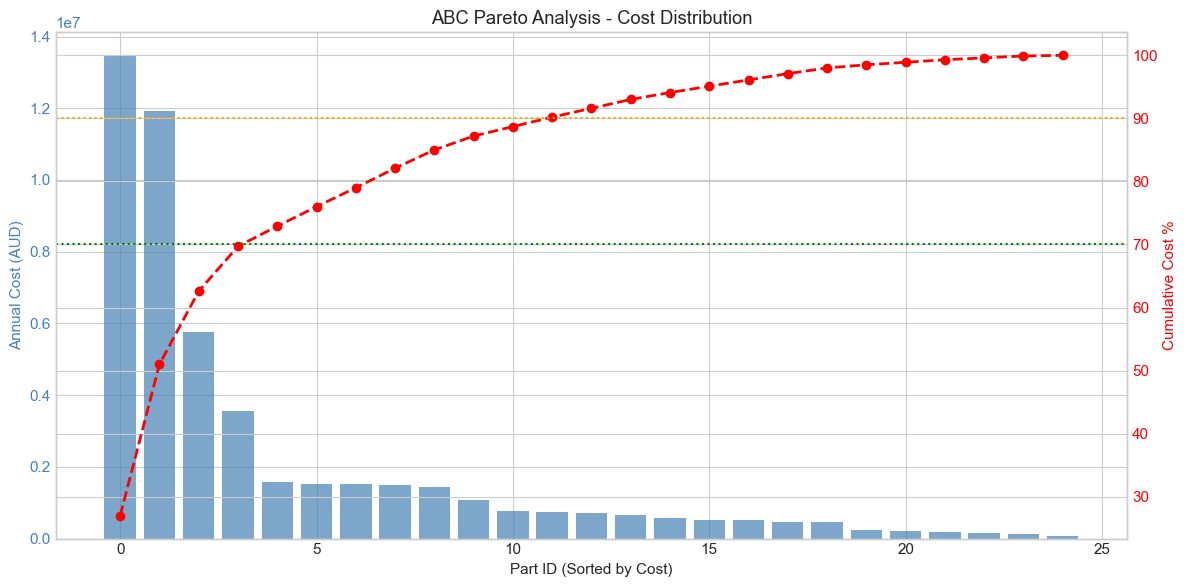

In [6]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bars for Annual Cost
ax1.bar(demand_df_sorted.index, demand_df_sorted['Annual_Cost_AUD'], color='steelblue', alpha=0.7, label='Annual Cost (AUD)')
ax1.set_xlabel('Part ID (Sorted by Cost)')
ax1.set_ylabel('Annual Cost (AUD)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Create secondary axis for Cumulative Percentage
ax2 = ax1.twinx()
ax2.plot(demand_df_sorted.index, demand_df_sorted['Cumulative_Cost_Pct'], color='red', marker='o', linestyle='--', linewidth=2, label='Cumulative %')
ax2.set_ylabel('Cumulative Cost %', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add thresholds
ax2.axhline(y=70, color='green', linestyle=':', label='Class A Threshold (70%)')
ax2.axhline(y=90, color='orange', linestyle=':', label='Class B Threshold (90%)')

plt.title('ABC Pareto Analysis - Cost Distribution')
fig.tight_layout()
plt.show()


5. Financial Impact Analysis

In [7]:
liebherr_revenue_aud = 635_000_000
inventory_percentage_baseline = 0.02
holding_cost_rate = 0.23
turnover_baseline = 2.0

baseline_inventory = liebherr_revenue_aud * inventory_percentage_baseline
baseline_holding_cost = baseline_inventory * holding_cost_rate

policy_parameters = {
    'A': {'turns': 4.0, 'days_on_hand': 365/4.0, 'policy': 'Local stocking + VMI'},
    'B': {'turns': 3.0, 'days_on_hand': 365/3.0, 'policy': 'Regional warehouse'},
    'C': {'turns': 6.0, 'days_on_hand': 365/6.0, 'policy': 'Central warehouse + scheduled delivery'}
}

optimized_inventory = {}
for abc_class, params in policy_parameters.items():
    class_data = demand_df_sorted[demand_df_sorted['ABC_Class'] == abc_class]
    class_total_cost = class_data['Annual_Cost_AUD'].sum()
    scaling_factor = baseline_inventory / total_annual_cost
    class_baseline_inventory = class_total_cost * scaling_factor
    class_optimized_inventory = class_baseline_inventory * (turnover_baseline / params['turns'])
    
    optimized_inventory[abc_class] = {
        'turns': params['turns'],
        'days_on_hand': params['days_on_hand'],
        'policy': params['policy'],
        'baseline_inventory': class_baseline_inventory,
        'optimized_inventory': class_optimized_inventory,
        'reduction': class_baseline_inventory - class_optimized_inventory,
        'reduction_pct': ((class_baseline_inventory - class_optimized_inventory) / class_baseline_inventory * 100)
    }

total_optimized_inventory = sum(v['optimized_inventory'] for v in optimized_inventory.values())
total_reduction = baseline_inventory - total_optimized_inventory
annual_savings = total_reduction * holding_cost_rate

print(f'\nBaseline Inventory: ${baseline_inventory:,.0f}')
print(f'Optimized Inventory: ${total_optimized_inventory:,.0f}')
print(f'Inventory Reduction: ${total_reduction:,.0f} ({(total_reduction/baseline_inventory*100):.1f}%)')
print(f'Annual Holding Cost Savings: ${annual_savings:,.0f}')



Baseline Inventory: $12,700,000
Optimized Inventory: $6,513,805
Inventory Reduction: $6,186,195 (48.7%)
Annual Holding Cost Savings: $1,422,825


5.1 Financial Impact Comparison

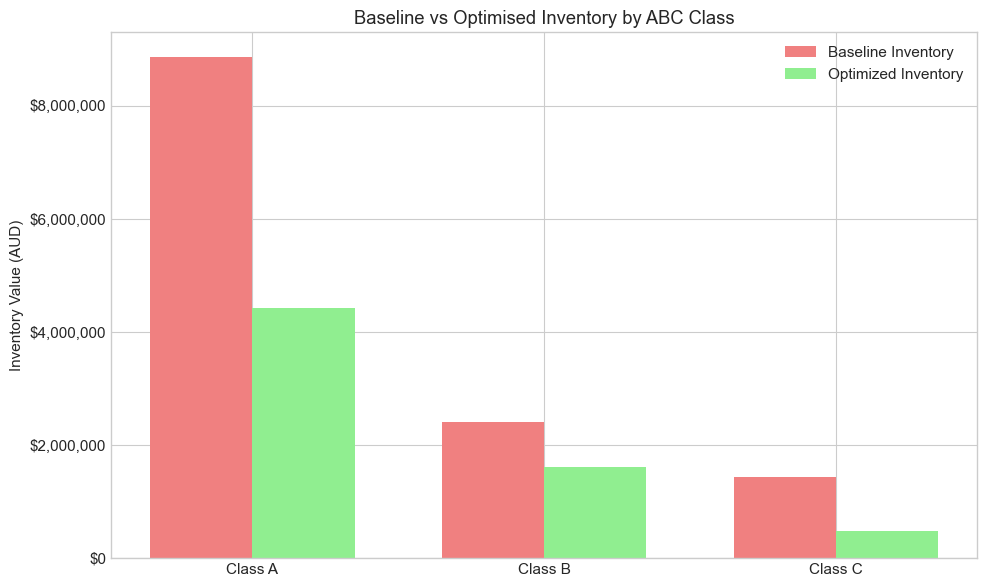

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

classes = ['Class A', 'Class B', 'Class C']
baseline_values = [optimized_inventory[c]['baseline_inventory'] for c in ['A', 'B', 'C']]
optimized_values = [optimized_inventory[c]['optimized_inventory'] for c in ['A', 'B', 'C']]

x = range(len(classes))
width = 0.35

bars1 = ax.bar([p - width/2 for p in x], baseline_values, width, label='Baseline Inventory', color='lightcoral')
bars2 = ax.bar([p + width/2 for p in x], optimized_values, width, label='Optimized Inventory', color='lightgreen')

ax.set_ylabel('Inventory Value (AUD)')
ax.set_title('Baseline vs Optimised Inventory by ABC Class')
ax.set_xticks(list(x))
ax.set_xticklabels(classes)
ax.legend()

# Format currency
import matplotlib.ticker as ticker
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()
